<a href="https://colab.research.google.com/github/AnumahAdeizaStephen/ResNet-Tutorial-/blob/main/2__Network_Training_(high-low).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **STAGE 1: DATA LOADING**

In [1]:
# @title a: imports
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy.special import erf
from scipy import ndimage
from scipy.interpolate import griddata # for reconstruction
from scipy import stats, signal, ndimage
from scipy.ndimage import zoom

from collections import defaultdict
from typing import List, Tuple, Optional, Dict, Any
import re

import warnings
import gc

# Torch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler

# Visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns

# Paths
from pathlib import Path
import pickle
from google.colab import drive
import os
import yaml

torch.manual_seed(42)
np.random.seed(42)

drive.mount('/content/drive')

DATA_PATH = 'drive/MyDrive/ColabNotebooks/ScatterAnalysis/data_32x32'

# BIN loading config
CONFIG = f'/content/config.yaml'
CFG = yaml.safe_load(open(CONFIG))


CHECKPOINT_DIR = "drive/MyDrive/ColabNotebooks/ScatterAnalysis/experiment_checkpoints"

# Fully preprocessed checkpoint
# FULLY_PROCESSED_PATH = "drive/MyDrive/ColabNotebooks/ScatterAnalysis/experiment_checkpoints/3d_fully_preprocessed_with_channel3_20260222_161746.pkl"

# Model save
# BEST_MODEL = f"{CHECKPOINT_DIR}/best_model.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

warnings.filterwarnings('ignore')

Mounted at /content/drive
Using device: cuda


In [2]:
# @title Helpers (Unused)
def stepish_func(x, x0, y0, h, a, b=0, c=0):
    return y0 + h / 2 * erf((x - x0) * a) + b * x + c * x**2


def gaussian(x, a, mu, sigma):
    return a * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def calculate_pulse_time_simple(w, threshold_ratio=0.5):
    baseline = np.mean(w[:10])  # First 10 samples as baseline
    peak = np.max(w)
    threshold = baseline + threshold_ratio * (peak - baseline)

    # Find where waveform crosses threshold
    above_threshold = w > threshold
    if not np.any(above_threshold):
        return np.nan

    # Find first crossing
    cross_idx = np.argmax(above_threshold)

    # Linear interpolation for sub-sample accuracy
    if cross_idx > 0:
        t0 = cross_idx - 1
        t1 = cross_idx
        y0 = w[t0] - threshold
        y1 = w[t1] - threshold
        if y0 != y1:
            fractional = -y0 / (y1 - y0)
            return t0 + fractional
    return cross_idx


def fit_waveform(args):
    w, x, p0 = args
    try:
        popt, _ = curve_fit(stepish_func, x, w, p0=p0, maxfev=10000)
        return popt[0]  # Return the pulse time (x0)
    except Exception:
        return np.nan


##########

def add_sharp_gaussian(image, center_x, center_y, amplitude, sigma=0.4):
    y, x = np.ogrid[: image.shape[0], : image.shape[1]]
    distance = np.sqrt((x - center_x) ** 2 + (y - center_y) ** 2)
    sigma = 0.15  # Sharper PSF
    gaussian = amplitude * np.exp(-(distance**2) / (2 * sigma**2))

    # ensure at least 50% of energy is within central pixel
    _ = gaussian[center_y, center_x] if (
        0 <= center_y < image.shape[0] and 0 <= center_x < image.shape[1]
    ) else amplitude
    return image + gaussian


def realistic_downsample(hr_image, low_res_size):
    """Realistic downsampling with optical blur"""
    blurred = ndimage.gaussian_filter(hr_image, sigma=0.8)

    # Average pooling
    block_size = hr_image.shape[0] // low_res_size
    lr_image = np.zeros((low_res_size, low_res_size))

    for i in range(low_res_size):
        for j in range(low_res_size):
            i_start = i * block_size
            i_end = min((i + 1) * block_size, hr_image.shape[0])
            j_start = j * block_size
            j_end = min((j + 1) * block_size, hr_image.shape[1])
            lr_image[i, j] = np.mean(blurred[i_start:i_end, j_start:j_end])
    return lr_image


def create_detector_data(ideas_loader, n_samples=1000, low_res_size=11, high_res_size=22):
    sampleData_in = np.zeros([n_samples, low_res_size, low_res_size])
    sampleData_out = np.zeros([n_samples, high_res_size, high_res_size])

    event_count = 0
    single_pixel_events = []

    # Collect single pixel events
    for timestamp, event_df in ideas_loader.event_groups:
        anodes = event_df[event_df.channel_flag == 1]
        if len(anodes) == 1:  # Single anode events only for clean training
            single_pixel_events.append((timestamp, event_df))
    print(f"Found {len(single_pixel_events)} single pixel events")

    if len(single_pixel_events) == 0:
        print("No single pixel events found! Using all events...")
        single_pixel_events = list(ideas_loader.event_groups)

    for timestamp, event_df in single_pixel_events:
        if event_count >= n_samples:
            break

        try:
            # Create high-resolution ground truth (22x22)
            hr_image = np.zeros((high_res_size, high_res_size))

            for _, row in event_df[event_df.channel_flag == 1].iterrows():
                if 1 <= row.x <= 11 and 1 <= row.y <= 11:
                    hr_x = (row.x - 1) * 2 + 1
                    hr_y = (row.y - 1) * 2 + 1

                    pulse_duration = 20
                    pulse_center = 80

                    # NOTE: 'amplitude' is not defined in your original snippet here.
                    # Leaving this logic as-is would error. This function is unused
                    # in your workflow, so we keep it unchanged except removing
                    # the undefined amplitude usage would require additional decisions.
                    # If you want to use it, tell me what amplitude should be.
                    for t in range(160):
                        time_dist = abs(t - pulse_center)
                        if time_dist < pulse_duration:
                            time_factor = np.exp(-(time_dist**2) / (2 * (pulse_duration / 4) ** 2))
                            # amplitude_scaled = amplitude * time_factor  # amplitude undefined
                            # hr_image = add_sharp_gaussian(hr_image, hr_x, hr_y, amplitude_scaled, sigma=0.15)
                            pass

            if np.max(hr_image) < 10:
                continue

            hr_max = np.max(hr_image)
            hr_image_normalized = hr_image / hr_max if hr_max > 0 else hr_image

            lr_image = realistic_downsample(hr_image_normalized, low_res_size)

            if np.max(lr_image) > 0.1 and np.max(hr_image_normalized) > 0.1:
                sampleData_in[event_count] = lr_image
                sampleData_out[event_count] = hr_image_normalized
                event_count += 1

            if event_count % 100 == 0:
                print(f"Processed {event_count}/{n_samples} real events...")

        except Exception as e:
            print(f"Error processing event: {e}")
            continue

    sampleData_in = sampleData_in[:event_count]
    sampleData_out = sampleData_out[:event_count]
    print(f"------------ Created {event_count} training samples from data")
    return sampleData_in, sampleData_out

In [3]:
# @title b: Data classes
class RasterScanTorchDataset(Dataset):
    def __init__(self, pixel_tensors, cathode_vectors, positions, transform=None):
        self.pixel_tensors = pixel_tensors
        self.cathode_vectors = cathode_vectors
        self.positions = positions
        self.transform = transform

    def __len__(self):
        return len(self.pixel_tensors)

    def __getitem__(self, idx):
        pixel_tensor = self.pixel_tensors[idx]
        cathode_vector = self.cathode_vectors[idx]
        position = self.positions[idx]

        if self.transform:
            pixel_tensor = self.transform(pixel_tensor)
            cathode_vector = self.transform(cathode_vector)

        return {
            'pixel_tensor': pixel_tensor,
            'cathode_vector': cathode_vector,
            'position': position,
        }


class RasterScanDataset:
    def __init__(
        self,
        bin_file_path,
        config_path=CONFIG,
        grid_size=(11, 11),
        target_type='amplitude',
        filter_empty=True,
        max_samples=None,
    ):
        self.bin_file_path = bin_file_path
        self.config = yaml.safe_load(open(config_path))
        self.grid_size = grid_size
        self.target_type = target_type
        self.filter_empty = filter_empty
        self.max_samples = max_samples

        self.pixel_stats = {'mean': None, 'std': None}
        self.cathode_stats = {'mean': None, 'std': None}
        self.target_mean = 0.0
        self.target_std = 1.0

        self.raster_positions = []
        self.pixel_tensors = []
        self.cathode_vectors = []
        self.metadata = []
        self.ground_truth_df = None

        self.df = None
        self.waveforms = None
        self.timestamps = None
        self.x_coords = None
        self.y_coords = None
        self.channel_flags = None
        self.event_groups = None

        self.load_binary_data()
        self.organize_by_raster_position()
        self.calculate_ground_truth_parallel()

        print("Creating target maps...")
        self.target_maps = self._create_target_maps()

        if self.filter_empty:
            self._filter_empty_samples()

        if self.max_samples is not None and self.max_samples < len(self.pixel_tensors):
            self._limit_samples()

    def _upsample_map(self, sparse_map, target_size=(22, 22)):
        zoom_factors = (target_size[0] / sparse_map.shape[0], target_size[1] / sparse_map.shape[1])
        upsampled = zoom(sparse_map, zoom_factors, order=1)
        return upsampled.astype(np.float32)

    def _filter_empty_samples(self):
        print("\n=== Filtering Empty Samples ===")
        original_count = len(self.target_maps)

        valid_indices = []
        for i in range(len(self.target_maps)):
            if np.max(self.target_maps[i]) > 0:
                valid_indices.append(i)

        print(f"Keeping {len(valid_indices)}/{original_count} samples with positive targets")

        self.pixel_tensors = self.pixel_tensors[valid_indices]
        self.cathode_vectors = self.cathode_vectors[valid_indices]
        self.target_maps = self.target_maps[valid_indices]
        self.raster_positions = self.raster_positions[valid_indices]
        self.metadata = [self.metadata[i] for i in valid_indices]

    def _limit_samples(self):
        print(f"\n=== Limiting to {self.max_samples} samples ===")

        event_ids_with_flag3 = set()
        if self.ground_truth_df is not None:
            flag3_events = self.ground_truth_df[self.ground_truth_df['channel_flag'] == 3]
            event_ids_with_flag3 = set(flag3_events['raster_event_id'].unique())
            print(f"Found {len(event_ids_with_flag3)} events with channel flag 3")

        all_indices = list(range(len(self.pixel_tensors)))
        flag3_indices = [i for i in all_indices if i in event_ids_with_flag3]
        other_indices = [i for i in all_indices if i not in event_ids_with_flag3]

        selected_indices = flag3_indices[: self.max_samples]
        if len(selected_indices) < self.max_samples:
            remaining = self.max_samples - len(selected_indices)
            selected_indices.extend(other_indices[:remaining])

        self.pixel_tensors = self.pixel_tensors[selected_indices]
        self.cathode_vectors = self.cathode_vectors[selected_indices]
        self.target_maps = self.target_maps[selected_indices]
        self.raster_positions = self.raster_positions[selected_indices]
        self.metadata = [self.metadata[i] for i in selected_indices]

        print(
            f"Selected {len(selected_indices)} samples "
            f"({min(len(flag3_indices), self.max_samples)} with channel flag 3)"
        )

    def get_data_dict(self):
        return {
            'pixel_tensors': torch.FloatTensor(self.pixel_tensors),
            'cathode_vectors': torch.FloatTensor(self.cathode_vectors)
            if self.cathode_vectors is not None
            else torch.zeros((len(self.pixel_tensors), 160)),
            'target_maps': torch.FloatTensor(self.target_maps),
            'positions': torch.FloatTensor(self.raster_positions)
            if self.raster_positions is not None
            else torch.zeros((len(self.pixel_tensors), 2)),
        }

    def load_binary_data(self):
        filename = self.bin_file_path
        outfilename = Path(filename).stem + ".npy"

        if os.path.exists(outfilename):
            print(f"Loading cached data from {outfilename}")
            with open(outfilename, "rb") as f:
                file_size = np.load(f)
                record_size = np.load(f)
                num_records = np.load(f)
                waveforms = np.load(f)
                timestamp = np.load(f)
                x = np.load(f)
                y = np.load(f)
                channel_flag = np.load(f)
        else:
            data_type = np.dtype(
                [
                    ("length", ">u2"),
                    ("log_type", ">u2"),
                    ("packet_count", ">u2"),
                    ("packet_flags", ">u1"),
                    ("system_number", ">u1"),
                    ("timestamp", ">u8"),
                    ("source_id", ">u1"),
                    ("trig_type", ">u1"),
                    ("user_status", ">u2"),
                    ("event_id", ">u4"),
                    ("pps_timestamp", ">u4"),
                    ("channel_flag", ">u1"),
                    ("cell_pointer", ">u1"),
                    ("x_address", ">u1"),
                    ("y_address", ">u1"),
                    ("waveforms", (">H", (160,))),
                ]
            )

            file_size = os.path.getsize(filename)
            record_size = 32 + 160 * 2
            num_records = file_size // record_size
            memmap = np.memmap(filename, dtype=data_type, mode="r", shape=(num_records))

            prev_timestamp = memmap["timestamp"][0]
            overflow_increment = 0
            adjusted_timestamps = np.zeros_like(memmap["timestamp"])
            for i, ts in enumerate(memmap["timestamp"]):
                if ts < prev_timestamp:
                    overflow_increment += prev_timestamp
                adjusted_timestamps[i] = ts + overflow_increment
                prev_timestamp = ts

            waveforms = memmap["waveforms"].byteswap().view(memmap["waveforms"].dtype.newbyteorder())
            timestamp = adjusted_timestamps.byteswap().view(adjusted_timestamps.dtype.newbyteorder())
            x = memmap["x_address"].byteswap().view(memmap["x_address"].dtype.newbyteorder())
            y = memmap["y_address"].byteswap().view(memmap["y_address"].dtype.newbyteorder())
            channel_flag = memmap["channel_flag"].byteswap().view(memmap["channel_flag"].dtype.newbyteorder())

            with open(outfilename, "wb") as f:
                np.save(f, file_size)
                np.save(f, record_size)
                np.save(f, num_records)
                np.save(f, waveforms)
                np.save(f, timestamp)
                np.save(f, x)
                np.save(f, y)
                np.save(f, channel_flag)

        self.waveforms = waveforms
        self.timestamps = timestamp
        self.x_coords = x
        self.y_coords = y
        self.channel_flags = channel_flag

        self.df = pd.DataFrame(
            {'timestamp': self.timestamps, 'x': self.x_coords, 'y': self.y_coords, 'channel_flag': self.channel_flags}
        )

        self.event_groups = self.df.groupby('timestamp')

        print(f"Loaded {len(self.waveforms)} waveform records")
        print(f"Data shapes - waveforms: {waveforms.shape}, timestamps: {timestamp.shape}")
        print(f"Found {len(self.event_groups)} unique events")

    def create_data_loaders(
        self,
        batch_size=8,
        train_ratio=0.7,
        val_ratio=0.15,
        test_ratio=0.15,
        shuffle=True,
        random_seed=42,
    ):
        data = self.get_data_dict()
        total_samples = len(self.pixel_tensors)

        indices = np.arange(total_samples)

        if shuffle:
            np.random.seed(random_seed)
            np.random.shuffle(indices)

        train_end = int(train_ratio * total_samples)
        val_end = train_end + int(val_ratio * total_samples)

        train_indices = indices[:train_end]
        val_indices = indices[train_end:val_end]
        test_indices = indices[val_end:]

        max_train_samples = 5000
        max_val_samples = 1000
        max_test_samples = 1000

        train_indices = train_indices[:max_train_samples]
        val_indices = val_indices[:max_val_samples]
        test_indices = test_indices[:max_test_samples]

        print(f"\n=== Data Split ===")
        print(f"Train: {len(train_indices)} samples")
        print(f"Val: {len(val_indices)} samples")
        print(f"Test: {len(test_indices)} samples")

        class SubsetDataset(torch.utils.data.Dataset):
            def __init__(self, data_dict, indices):
                self.data = data_dict
                self.indices = indices

            def __len__(self):
                return len(self.indices)

            def __getitem__(self, idx):
                actual_idx = self.indices[idx]
                return {
                    'pixel_tensor': self.data['pixel_tensors'][actual_idx],
                    'cathode_vector': self.data['cathode_vectors'][actual_idx],
                    'target_map': self.data['target_maps'][actual_idx],
                    'position': self.data['positions'][actual_idx],
                }

        train_dataset = SubsetDataset(data, train_indices)
        val_dataset = SubsetDataset(data, val_indices)
        test_dataset = SubsetDataset(data, test_indices)

        train_loader = torch.utils.data.DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=0,
            pin_memory=False,
            persistent_workers=False,
        )
        val_loader = torch.utils.data.DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=False,
            persistent_workers=False,
        )
        test_loader = torch.utils.data.DataLoader(
            test_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=False,
            persistent_workers=False,
        )

        return train_loader, val_loader, test_loader

    def _create_target_maps(self):
        target_maps = []

        for event_idx in range(len(self.pixel_tensors)):
            sparse_map = np.zeros((11, 11), dtype=np.float32)

            event_gt = self.ground_truth_df[
                (self.ground_truth_df['raster_event_id'] == event_idx) & (self.ground_truth_df['pixel_type'] != 0)
            ]

            for _, row in event_gt.iterrows():
                x = int(row['x'])
                y = int(row['y'])

                if 0 <= x <= 10 and 0 <= y <= 10:
                    if self.target_type == 'amplitude':
                        amplitude_value = row['amplitude']
                        if amplitude_value > 0:
                            sparse_map[x, y] = amplitude_value
                    elif self.target_type == 'pulse_time':
                        sparse_map[x, y] = row['pulse_time']
                    elif self.target_type == 'pixel_type':
                        sparse_map[x, y] = row['pixel_type']

            upsampled_map = self._upsample_map(sparse_map, target_size=(22, 22))
            target_maps.append(upsampled_map)

        return np.array(target_maps)

    def organize_by_raster_position(self):
        """
        Store tensor consistently as [y, x, t] so that:
          - first index is vertical (y), second is horizontal (x),
          - imshow() displays x on the horizontal axis, y on the vertical axis without transposes.
        This also makes it consistent with visualize_raw_sample().
        """
        pixel_tensors_list = []
        cathode_vectors_list = []

        for timestamp, group_df in self.event_groups:
            # NOTE: pixel_tensor now [y, x, t]
            pixel_tensor = np.zeros((self.grid_size[0], self.grid_size[1], 160), dtype=np.float32)

            anodes_df = group_df[group_df['channel_flag'].isin([1, 3])]

            for idx, row in anodes_df.iterrows():
                x_pos = int(row['x'])
                y_pos = int(row['y'])

                if 0 <= x_pos <= 10 and 0 <= y_pos <= 10:
                    waveform_idx = idx
                    if 0 <= waveform_idx < len(self.waveforms):
                        w = self.waveforms[waveform_idx].astype(np.float32)
                        wcfg = self.config['waveform']
                        low = np.mean(w[wcfg["anode_low_lim"][0] : wcfg["anode_low_lim"][1]])
                        high = np.mean(w[wcfg["anode_high_lim"][0] : wcfg["anode_high_lim"][1]])
                        amplitude = max(0.0, float(high - low))

                        if np.max(np.abs(w)) > 0 and amplitude > 0:
                            candidate = w * (amplitude / np.max(np.abs(w)))
                            # FIX: store as [y, x, t]
                            pixel_tensor[y_pos, x_pos, :] += candidate

            cathode_vector = np.zeros(160, dtype=np.float32)
            cathodes_df = group_df[group_df['channel_flag'] == 2]
            if len(cathodes_df) > 0:
                cath_row = cathodes_df.iloc[0]
                waveform_idx = cath_row.name

                if 0 <= waveform_idx < len(self.waveforms):
                    cath_w = self.waveforms[waveform_idx].astype(np.float32)
                    cath_min, cath_max = np.min(cath_w), np.max(cath_w)
                    if cath_max - cath_min > 0:
                        cathode_vector = (cath_w - cath_min) / (cath_max - cath_min)
                    else:
                        cathode_vector = np.zeros_like(cath_w)

            pixel_tensor = -pixel_tensor  # NEGATE to match cathode polarity

            raster_x, raster_y = self.extract_raster_position(timestamp, group_df)
            pixel_tensors_list.append(pixel_tensor)
            cathode_vectors_list.append(cathode_vector)
            self.raster_positions.append((raster_x, raster_y))

            self.metadata.append(
                {
                    'timestamp': timestamp,
                    'raster_x': raster_x,
                    'raster_y': raster_y,
                    'num_anodes': len(anodes_df),
                    'num_main_anodes': len(group_df[group_df['channel_flag'] == 3]),
                    'num_cathodes': len(cathodes_df),
                    'num_channel1': len(group_df[group_df['channel_flag'] == 1]),
                    'num_channel2': len(group_df[group_df['channel_flag'] == 2]),
                    'num_channel3': len(group_df[group_df['channel_flag'] == 3]),
                }
            )

        self.pixel_tensors = np.array(pixel_tensors_list)
        self.cathode_vectors = np.array(cathode_vectors_list)
        self.raster_positions = np.array(self.raster_positions)

    def calculate_ground_truth_parallel(self):
        amplitudes = []
        pulse_times = []
        event_indices = []
        pixel_types = []
        raster_event_ids = []
        pixel_coords = []
        channel_flags = []

        for event_idx, (timestamp, group_df) in enumerate(tqdm(self.event_groups, total=len(self.event_groups))):
            for idx, row in group_df.iterrows():
                waveform_idx = idx
                w = self.waveforms[waveform_idx]

                if row.channel_flag in [1, 3]:
                    wcfg = self.config['waveform']
                    low = np.mean(w[wcfg["anode_low_lim"][0] : wcfg["anode_low_lim"][1]])
                    high = np.mean(w[wcfg["anode_high_lim"][0] : wcfg["anode_high_lim"][1]])
                    amplitude = high - low

                    pulse_time = self.calculate_pulse_time_simple(w, 0.3)

                    if row.channel_flag == 3:
                        pixel_type = 3
                    elif row.channel_flag == 1:
                        pixel_type = 1
                    else:
                        continue

                elif row.channel_flag == 2:
                    wcfg = self.config['waveform']
                    low = np.mean(w[wcfg["cathode_low_lim"][0] : wcfg["cathode_low_lim"][1]])
                    high = np.mean(w[wcfg["cathode_high_lim"][0] : wcfg["cathode_high_lim"][1]])
                    amplitude = high - low

                    pulse_time = self.calculate_pulse_time_simple(w, 0.3)
                    pixel_type = 0
                else:
                    continue

                amplitudes.append(amplitude)
                pulse_times.append(pulse_time)
                event_indices.append(waveform_idx)
                pixel_types.append(pixel_type)
                raster_event_ids.append(event_idx)
                pixel_coords.append((row.x, row.y))
                channel_flags.append(row.channel_flag)

        self.ground_truth_df = pd.DataFrame(
            {
                'original_index': event_indices,
                'amplitude': amplitudes,
                'pulse_time': pulse_times,
                'pixel_type': pixel_types,
                'raster_event_id': raster_event_ids,
                'x': [c[0] for c in pixel_coords],
                'y': [c[1] for c in pixel_coords],
                'channel_flag': channel_flags,
            }
        )

        if hasattr(self, 'ground_truth_df') and 'channel_flag' in self.ground_truth_df.columns:
            print("Channel flag distribution:")
            print(self.ground_truth_df['channel_flag'].value_counts())

    def calculate_pulse_time_simple(self, w, threshold_ratio=0.3):
        baseline = np.mean(w[:10])
        peak = np.max(w)
        threshold = baseline + threshold_ratio * (peak - baseline)

        above_threshold = w > threshold
        if not np.any(above_threshold):
            return np.nan

        cross_idx = np.argmax(above_threshold)

        if cross_idx > 0:
            t0 = cross_idx - 1
            t1 = cross_idx
            y0 = w[t0] - threshold
            y1 = w[t1] - threshold
            if y0 != y1:
                fractional = -y0 / (y1 - y0)
                return t0 + fractional
        return cross_idx

    def is_main_event(self, event_df, x, y):
        main_anodes = event_df[(event_df.channel_flag == 3) & (event_df.x == x) & (event_df.y == y)]
        if len(main_anodes) > 0:
            return True

        anodes = event_df[event_df.channel_flag == 1]
        if len(anodes) == 1:
            return True

        amplitudes = []
        for idx, row in anodes.iterrows():
            w = self.waveforms[idx]
            low_lim = self.config['waveform']["anode_low_lim"]
            high_lim = self.config['waveform']["anode_high_lim"]
            low = np.mean(w[low_lim[0] : low_lim[1]])
            high = np.mean(w[high_lim[0] : high_lim[1]])
            amplitudes.append(high - low)

        if len(amplitudes) > 0:
            max_amp_idx = np.argmax(amplitudes)
            main_anode = anodes.iloc[max_amp_idx]
            return main_anode.x == x and main_anode.y == y

        return False

    def extract_raster_position(self, timestamp, group_df):
        filename = Path(self.bin_file_path).stem
        match = re.search(r'x([-\d.]+)_y([-\d.]+)', filename)
        if match:
            return float(match.group(1)), float(match.group(2))
        return 0.0, 0.0

    def get_training_data(self, target_type='amplitude', use_augmented=False):
        if use_augmented and hasattr(self, 'pixel_tensors_augmented'):
            pixel_data = self.pixel_tensors_augmented
            cathode_data = self.cathode_vectors_augmented
        else:
            pixel_data = self.pixel_tensors
            cathode_data = self.cathode_vectors

        target_maps = []

        for event_idx in range(len(pixel_data)):
            target_map = np.zeros((11, 11), dtype=np.float32)

            event_gt = self.ground_truth_df[
                (self.ground_truth_df['raster_event_id'] == event_idx) & (self.ground_truth_df['pixel_type'] != 0)
            ]

            for _, row in event_gt.iterrows():
                x, y = int(row['x']), int(row['y'])

                if 0 <= x <= 10 and 0 <= y <= 10:
                    if target_type == 'amplitude':
                        target_map[y, x] = row['amplitude']  # keep [y,x] for maps
                    elif target_type == 'pulse_time':
                        target_map[y, x] = row['pulse_time']
                    elif target_type == 'pixel_type':
                        target_map[y, x] = row['pixel_type']

            target_maps.append(target_map)

        return {
            'pixel_tensors': torch.FloatTensor(pixel_data),
            'cathode_vectors': torch.FloatTensor(cathode_data),
            'target_maps': torch.FloatTensor(np.array(target_maps)),
            'positions': torch.FloatTensor(self.raster_positions),
            'ground_truth': self.ground_truth_df,
        }

    def __len__(self):
        return len(self.pixel_tensors)

    def __getitem__(self, idx):
        return {
            'pixel_tensor': torch.FloatTensor(self.pixel_tensors[idx]),
            'cathode_vector': torch.FloatTensor(self.cathode_vectors[idx]),
            'position': torch.FloatTensor(self.raster_positions[idx]),
        }

### **STAGE 2: Neural Network**

In [4]:
# @title s2: NN Building Blocks
class ResNetBlock3D(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        downsample_time: bool = False,
        kernel_size: int = 3,
        stride: int = 1,
        activation: str = 'leaky_relu',
    ):
        super().__init__()
        self.downsample_time = downsample_time

        self.conv1 = nn.Conv3d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            stride=(1, 1, stride if downsample_time else 1),
        )
        self.bn1 = nn.BatchNorm3d(out_channels)

        self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size=kernel_size, padding=kernel_size // 2, stride=1)
        self.bn2 = nn.BatchNorm3d(out_channels)

        if activation == 'leaky_relu':
            self.activation = nn.LeakyReLU(negative_slope=0.01, inplace=True)
        elif activation == 'relu':
            self.activation = nn.ReLU(inplace=True)
        else:
            self.activation = nn.SiLU(inplace=True)

        self.skip_conv = None
        if in_channels != out_channels or downsample_time:
            self.skip_conv = nn.Conv3d(
                in_channels, out_channels, kernel_size=1, stride=(1, 1, stride if downsample_time else 1)
            )
            self.skip_bn = nn.BatchNorm3d(out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.activation(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.skip_conv is not None:
            identity = self.skip_conv(identity)
            identity = self.skip_bn(identity)

        out += identity
        out = self.activation(out)

        return out


class ResNetBlock1D(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        downsample: bool = False,
        kernel_size: int = 3,
        stride: int = 1,
        activation: str = 'leaky_relu',
    ):
        super().__init__()
        self.downsample = downsample

        self.conv1 = nn.Conv1d(
            in_channels, out_channels, kernel_size=kernel_size, padding=kernel_size // 2, stride=stride if downsample else 1
        )
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, padding=kernel_size // 2, stride=1)
        self.bn2 = nn.BatchNorm1d(out_channels)

        if activation == 'leaky_relu':
            self.activation = nn.LeakyReLU(negative_slope=0.01, inplace=True)
        elif activation == 'relu':
            self.activation = nn.ReLU(inplace=True)
        else:
            self.activation = nn.SiLU(inplace=True)

        self.skip_conv = None
        if in_channels != out_channels or downsample:
            self.skip_conv = nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride if downsample else 1)
            self.skip_bn = nn.BatchNorm1d(out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.activation(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.skip_conv is not None:
            identity = self.skip_conv(identity)
            identity = self.skip_bn(identity)

        out += identity
        out = self.activation(out)

        return out


class RasterScanResNet(nn.Module):
    def __init__(
        self,
        input_shape: Tuple[int, int, int] = (11, 11, 160),
        output_shape: Tuple[int, int] = (22, 22),
        pixel_channels: List[int] = [1, 8, 16, 32],
        cathode_channels: List[int] = [1, 32, 64, 64],
        fusion_channels: int = 64,
        final_channels: List[int] = [64, 32, 16],
        downsample_stages: List[int] = [1, 2, 3],
        dropout_rate: float = 0.1,
        activation: str = 'leaky_relu',
        use_baseline_predictor: bool = True,
    ):
        super().__init__()

        self.input_shape = input_shape
        self.output_shape = output_shape
        self.use_baseline_predictor = use_baseline_predictor

        # Pixel branch
        self.pixel_branch = nn.ModuleList()
        self.pixel_initial = nn.Sequential(
            nn.Conv3d(1, pixel_channels[0], kernel_size=3, padding=1),
            nn.BatchNorm3d(pixel_channels[0]),
            nn.LeakyReLU(0.01, inplace=True) if activation == 'leaky_relu' else nn.ReLU(inplace=True),
        )
        for i in range(len(pixel_channels) - 1):
            downsample_time = (i + 1) in downsample_stages
            block = ResNetBlock3D(pixel_channels[i], pixel_channels[i + 1], downsample_time=downsample_time, activation=activation)
            self.pixel_branch.append(block)

        # Cathode branch
        self.cathode_branch = nn.ModuleList()
        self.cathode_initial = nn.Sequential(
            nn.Conv1d(1, cathode_channels[0], kernel_size=3, padding=1),
            nn.BatchNorm1d(cathode_channels[0]),
            nn.LeakyReLU(0.01, inplace=True) if activation == 'leaky_relu' else nn.ReLU(inplace=True),
        )
        for i in range(len(cathode_channels) - 1):
            block = ResNetBlock1D(cathode_channels[i], cathode_channels[i + 1], downsample=True, activation=activation)
            self.cathode_branch.append(block)

        # Fusion
        self.fusion_projection = nn.Sequential(
            nn.Conv1d(cathode_channels[-1], fusion_channels, kernel_size=1),
            nn.BatchNorm1d(fusion_channels),
            nn.LeakyReLU(0.01, inplace=True) if activation == 'leaky_relu' else nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
        )

        # Temporal collapse
        self.temporal_collapse = nn.Sequential(
            nn.Conv3d(pixel_channels[-1] * 2, pixel_channels[-1], kernel_size=(1, 1, 3), padding=(0, 0, 1)),
            nn.BatchNorm3d(pixel_channels[-1]),
            nn.LeakyReLU(0.01, inplace=True) if activation == 'leaky_relu' else nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d((input_shape[0], input_shape[1], 1)),
            nn.Flatten(start_dim=2, end_dim=3),
        )

        # Spatial processing
        self.spatial_upsample = nn.Upsample(size=output_shape, mode='bilinear', align_corners=False)
        self.spatial_blocks = nn.ModuleList()
        current_channels = pixel_channels[-1]
        for out_channels in final_channels:
            block = nn.Sequential(
                nn.Conv2d(current_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.LeakyReLU(0.01, inplace=True) if activation == 'leaky_relu' else nn.ReLU(inplace=True),
                nn.Dropout2d(dropout_rate),
            )
            self.spatial_blocks.append(block)
            current_channels = out_channels

        self.final_output = nn.Sequential(
            nn.Conv2d(current_channels, 1, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        # Baseline predictor (per-pixel confidence)
        if self.use_baseline_predictor:
            self.baseline_predictor = nn.Sequential(
                nn.Conv3d(pixel_channels[-1], 16, kernel_size=1),
                nn.BatchNorm3d(16),
                nn.LeakyReLU(0.01, inplace=True),
                nn.AdaptiveAvgPool3d((input_shape[0], input_shape[1], 1)),
                nn.Flatten(start_dim=2, end_dim=3),
            )
            self.baseline_conv2d = nn.Sequential(
                nn.Conv2d(16, 8, kernel_size=3, padding=1),
                nn.BatchNorm2d(8),
                nn.LeakyReLU(0.01, inplace=True),
                nn.Conv2d(8, 1, kernel_size=1),
                nn.Upsample(size=output_shape, mode='bilinear', align_corners=False),
                nn.Sigmoid(),
            )

            self.input_magnitude_gate = nn.Sequential(
                nn.AdaptiveAvgPool3d(1),
                nn.Flatten(),
                nn.Linear(pixel_channels[-1], 1),
                nn.Sigmoid(),
            )
        else:
            self.baseline_predictor = None
            self.baseline_conv2d = None
            self.input_magnitude_gate = None

        self._initialize_weights()

    def forward(self, pixel_tensor: torch.Tensor, cathode_vector: torch.Tensor) -> torch.Tensor:
        batch_size = pixel_tensor.shape[0]

        x_pixel = pixel_tensor.unsqueeze(1)
        x_pixel = self.pixel_initial(x_pixel)
        for block in self.pixel_branch:
            x_pixel = block(x_pixel)

        x_cathode = cathode_vector.unsqueeze(1)
        x_cathode = self.cathode_initial(x_cathode)
        for block in self.cathode_branch:
            x_cathode = block(x_cathode)

        cathode_features = self.fusion_projection(x_cathode)
        compressed_time = x_pixel.shape[-1]
        cathode_features = F.interpolate(cathode_features, size=compressed_time, mode='linear', align_corners=False)
        cathode_features = cathode_features.unsqueeze(2).unsqueeze(3)
        cathode_features = cathode_features.expand(-1, -1, x_pixel.shape[2], x_pixel.shape[3], -1)

        fused_features = torch.cat([x_pixel, cathode_features], dim=1)

        if self.use_baseline_predictor:
            baseline_features = self.baseline_predictor(x_pixel)
            baseline_map = self.baseline_conv2d(baseline_features)

            input_gate = self.input_magnitude_gate(x_pixel).unsqueeze(-1).unsqueeze(-1)
            baseline_map = baseline_map * input_gate

            baseline_map = torch.where(baseline_map > 0.05, baseline_map, torch.zeros_like(baseline_map))

        spatial_features = self.temporal_collapse(fused_features)
        spatial_features = spatial_features.view(batch_size, -1, self.input_shape[0], self.input_shape[1])

        spatial_features = self.spatial_upsample(spatial_features)
        for block in self.spatial_blocks:
            spatial_features = block(spatial_features)

        prediction_map = self.final_output(spatial_features).squeeze(1)

        if self.use_baseline_predictor:
            prediction_map = prediction_map * baseline_map.squeeze(1)

        return prediction_map

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv1d, nn.Conv2d, nn.Conv3d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        if hasattr(self, 'final_output') and isinstance(self.final_output, nn.Sequential):
            for mm in self.final_output:
                if isinstance(mm, nn.Conv2d) and mm.bias is not None:
                    nn.init.constant_(mm.bias, -2.0)


# ============================================================================
# Training Class
class RasterScanTrainer:
    def __init__(self, model, train_loader, val_loader, device, config):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.config = config

        self.max_memory_usage = config.get('max_memory_gb', 2)
        self.mixed_precision = config.get('mixed_precision', True) and torch.cuda.is_available()

        if config.get('loss_function', 'mse') == 'mse':
            self.criterion = nn.MSELoss()
        elif config['loss_function'] == 'l1':
            self.criterion = nn.L1Loss()
        else:
            self.criterion = nn.MSELoss()

        if config.get('optimizer', 'adam') == 'adamw':
            self.optimizer = torch.optim.AdamW(
                model.parameters(),
                lr=config.get('learning_rate', 1e-3),
                weight_decay=config.get('weight_decay', 1e-4),
            )
        else:
            self.optimizer = torch.optim.Adam(
                model.parameters(),
                lr=config.get('learning_rate', 1e-3),
                weight_decay=config.get('weight_decay', 1e-4),
            )

        if config.get('scheduler', 'cosine') == 'cosine':
            self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                self.optimizer, T_max=config.get('epochs', 20), eta_min=config.get('min_lr', 1e-6)
            )
        elif config.get('scheduler') == 'plateau':
            self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                self.optimizer,
                mode='min',
                patience=config.get('scheduler_patience', 5),
                factor=config.get('scheduler_factor', 0.5),
            )
        else:
            self.scheduler = None

        self.history = {'train_loss': [], 'val_loss': [], 'learning_rates': []}

        self.best_val_loss = float('inf')
        self.patience_counter = 0
        self.patience = config.get('early_stopping_patience', 20)
        self.gradient_accumulation_steps = config.get('gradient_accumulation_steps', 2)
        self.scaler = GradScaler() if torch.cuda.is_available() else None

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0
        num_batches = 0

        self.optimizer.zero_grad()

        for batch_idx, batch in enumerate(tqdm(self.train_loader, desc="Training", leave=False)):
            if batch_idx % 10 == 0 and torch.cuda.is_available():
                torch.cuda.empty_cache()

            pixel_tensor = batch['pixel_tensor'].to(self.device)
            cathode_vector = batch['cathode_vector'].to(self.device)
            target_map = batch['target_map'].to(self.device)

            with autocast(enabled=self.mixed_precision):
                pred_map = self.model(pixel_tensor, cathode_vector)
                loss = self.criterion(pred_map, target_map)
                loss = loss / self.gradient_accumulation_steps

            if self.scaler:
                self.scaler.scale(loss).backward()
            else:
                loss.backward()

            if (batch_idx + 1) % self.gradient_accumulation_steps == 0:
                if self.scaler:
                    self.scaler.unscale_(self.optimizer)
                    if self.config.get('gradient_clip', 0) > 0:
                        torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config['gradient_clip'])
                    self.scaler.step(self.optimizer)
                    self.scaler.update()
                else:
                    if self.config.get('gradient_clip', 0) > 0:
                        torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config['gradient_clip'])
                    self.optimizer.step()

                self.optimizer.zero_grad()

            total_loss += loss.item() * self.gradient_accumulation_steps
            num_batches += 1

            del pixel_tensor, cathode_vector, target_map, pred_map, loss
            if torch.cuda.is_available():
                torch.cuda.synchronize()

        return total_loss / max(num_batches, 1)

    def validate(self):
        self.model.eval()
        total_loss = 0.0
        num_batches = 0

        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc="Validation", leave=False):
                pixel_tensor = batch['pixel_tensor'].to(self.device)
                cathode_vector = batch['cathode_vector'].to(self.device)
                target_map = batch['target_map'].to(self.device)

                pred_map = self.model(pixel_tensor, cathode_vector)
                loss = self.criterion(pred_map, target_map)

                total_loss += loss.item()
                num_batches += 1

        return total_loss / max(num_batches, 1)

    def train(self, num_epochs):
        print(f"Starting training for {num_epochs} epochs")
        print(f"Training samples: {len(self.train_loader.dataset)}")
        print(f"Validation samples: {len(self.val_loader.dataset)}")

        for epoch in range(num_epochs):
            train_loss = self.train_epoch()
            val_loss = self.validate()

            if self.scheduler is not None:
                if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    self.scheduler.step(val_loss)
                else:
                    self.scheduler.step()

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['learning_rates'].append(self.optimizer.param_groups[0]['lr'])

            if (epoch + 1) % self.config.get('print_every', 1) == 0:
                lr = self.optimizer.param_groups[0]['lr']
                arrow = '↓' if epoch > 0 and lr < self.history['learning_rates'][-2] else '→'
                print(
                    f"Epoch {epoch+1:04d}/{num_epochs:04d} | "
                    f"Train Loss: {train_loss:.6f} | "
                    f"Val Loss: {val_loss:.6f} | "
                    f"LR: {lr:.2e} {arrow}"
                )

            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.patience_counter = 0
                torch.save(
                    {
                        'epoch': epoch,
                        'model_state_dict': self.model.state_dict(),
                        'optimizer_state_dict': self.optimizer.state_dict(),
                        'val_loss': val_loss,
                        'history': self.history,
                    },
                    'best_model.pt',
                )
            else:
                self.patience_counter += 1

            if self.patience_counter >= self.patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        print(f"Training completed. Best validation loss: {self.best_val_loss:.6f}")

        checkpoint = torch.load('best_model.pt', map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])

    def visualize_training(self):
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        axes[0].plot(self.history['train_loss'], label='Train Loss')
        axes[0].plot(self.history['val_loss'], label='Val Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training History')
        axes[0].legend()
        axes[0].grid(True)

        epochs = range(1, len(self.history['learning_rates']) + 1)
        axes[1].plot(epochs, self.history['learning_rates'], marker='o', markersize=3)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Learning Rate')
        axes[1].set_title('Learning Rate Schedule')
        axes[1].grid(True)
        axes[1].set_yscale('log')

        if len(self.history['learning_rates']) > 0:
            axes[1].annotate(
                f'Start: {self.history["learning_rates"][0]:.2e}',
                xy=(1, self.history['learning_rates'][0]),
                xytext=(5, 5),
                textcoords='offset points',
            )
            axes[1].annotate(
                f'End: {self.history["learning_rates"][-1]:.2e}',
                xy=(len(self.history['learning_rates']), self.history['learning_rates'][-1]),
                xytext=(5, 5),
                textcoords='offset points',
            )

        if len(self.history['learning_rates']) > 1:
            lr_changes = [self.history['learning_rates'][i] - self.history['learning_rates'][i - 1] for i in range(1, len(self.history['learning_rates']))]
            axes[2].plot(range(2, len(self.history['learning_rates']) + 1), lr_changes, color='red', marker='o', markersize=3)
            axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.3)
            axes[2].set_xlabel('Epoch')
            axes[2].set_ylabel('Δ Learning Rate')
            axes[2].set_title('Learning Rate Changes')
            axes[2].grid(True)

        plt.tight_layout()
        plt.show()

In [5]:
# @title i. Config & Data loading
TRAIN_EPOCHS = 10
DATA_SAMPLES_TO_LOAD = 5000
SAMPLES_TO_VISUALIZE = 3

config = {
    'model': {
        'pixel_channels': [1, 8, 16, 32],
        'cathode_channels': [1, 32, 64, 64],
        'fusion_channels': 32,
        'final_channels': [32, 16, 8],
        'downsample_stages': [1, 2],
        'dropout_rate': 0.2,
        'activation': 'leaky_relu',
        'use_baseline_predictor': True,
    },
    'training': {
        'batch_size': 8,
        'epochs': TRAIN_EPOCHS,
        'learning_rate': 5e-4,
        'weight_decay': 1e-5,
        'gradient_clip': 0.5,
        'gradient_accumulation_steps': 1,
        'loss_function': 'mse',
        'optimizer': 'adam',
        'scheduler': 'cosine',
        'min_lr': 1e-6,
        'early_stopping_patience': 8,
        'print_every': 1,
        'max_memory_gb': 1,
        'mixed_precision': True,
    },
}

print("Loading Dataset from BIN file")
print("=" * 50)

bin_list = [
    f'/content/scan_x2.000_y10.000_2026-03-03__18_22_08.bin',
]

dataset = RasterScanDataset(
    bin_file_path=bin_list[0],
    target_type='amplitude',
    filter_empty=True,
    max_samples=DATA_SAMPLES_TO_LOAD,
)

print("Creating Data Loaders")
print("=" * 50)

data_dict = dataset.get_data_dict()
total_samples = len(dataset.pixel_tensors)

indices = np.arange(total_samples)
np.random.seed(42)
np.random.shuffle(indices)

train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15
train_end = int(train_ratio * total_samples)
val_end = train_end + int(val_ratio * total_samples)

train_indices = indices[:train_end][:5000]
val_indices = indices[train_end:val_end][:1000]
test_indices = indices[val_end:][:1000]

print(f"\n=== Data Split ===")
print(f"Train: {len(train_indices)} samples")
print(f"Val: {len(val_indices)} samples")
print(f"Test: {len(test_indices)} samples")


class SubsetDataset(torch.utils.data.Dataset):
    def __init__(self, data_dict, indices):
        self.data = data_dict
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        actual_idx = self.indices[idx]
        return {
            'pixel_tensor': self.data['pixel_tensors'][actual_idx],
            'cathode_vector': self.data['cathode_vectors'][actual_idx],
            'target_map': self.data['target_maps'][actual_idx],
            'position': self.data['positions'][actual_idx],
        }


train_dataset = SubsetDataset(data_dict, train_indices)
val_dataset = SubsetDataset(data_dict, val_indices)
test_dataset = SubsetDataset(data_dict, test_indices)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=config['training']['batch_size'], shuffle=True, num_workers=0)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=config['training']['batch_size'], shuffle=False, num_workers=0)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=config['training']['batch_size'], shuffle=False, num_workers=0)

Loading Dataset from BIN file
Loaded 110913 waveform records
Data shapes - waveforms: (110913, 160), timestamps: (110913,)
Found 9054 unique events


100%|██████████| 9054/9054 [00:19<00:00, 464.17it/s]


Channel flag distribution:
channel_flag
1    88609
3    13250
2     9054
Name: count, dtype: int64
Creating target maps...

=== Filtering Empty Samples ===
Keeping 7840/9054 samples with positive targets

=== Limiting to 5000 samples ===
Found 9054 events with channel flag 3
Selected 5000 samples (5000 with channel flag 3)
Creating Data Loaders

=== Data Split ===
Train: 3500 samples
Val: 750 samples
Test: 750 samples


Initializing Model
Total parameters: 134,143
Trainable parameters: 134,143
Starting Training
Starting training for 10 epochs
Training samples: 3500
Validation samples: 750


Epoch 0001/0010 | Train Loss: 5843.302836 | Val Loss: 5220.084678 | LR: 4.88e-04 →


Epoch 0002/0010 | Train Loss: 5421.299788 | Val Loss: 4791.989973 | LR: 4.52e-04 ↓


Epoch 0003/0010 | Train Loss: 4914.608478 | Val Loss: 4509.350530 | LR: 3.97e-04 ↓


Epoch 0004/0010 | Train Loss: 4393.957213 | Val Loss: 4045.921298 | LR: 3.28e-04 ↓


...

Epoch 0006/0010 | Train Loss: 3599.034078 | Val Loss: 3324.687638 | LR: 1.73e-04 ↓


Epoch 0007/0010 | Train Loss: 3337.368904 | Val Loss: 2980.221322 | LR: 1.04e-04 ↓


Epoch 0008/0010 | Train Loss: 3139.804162 | Val Loss: 2904.642381 | LR: 4.87e-05 ↓


Epoch 0009/0010 | Train Loss: 3001.913744 | Val Loss: 2779.957674 | LR: 1.32e-05 ↓


Epoch 0010/0010 | Train Loss: 2948.263261 | Val Loss: 3107.694013 | LR: 1.00e-06 ↓
Training completed. Best validation loss: 2779.957674

Visualizing Training Results


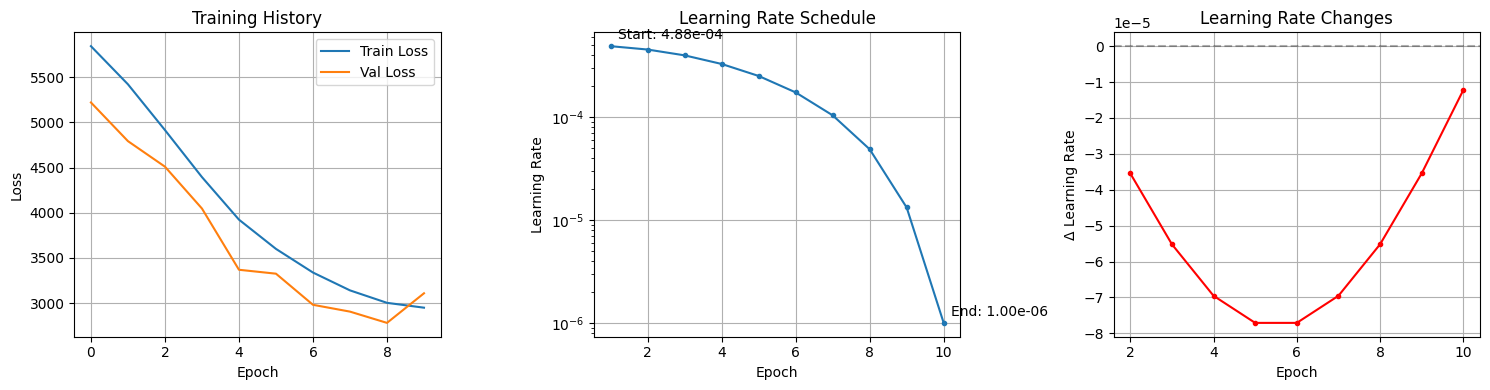

In [6]:
# @title ii. Train model
print("Initializing Model")
print("=" * 50)

model = RasterScanResNet(input_shape=(11, 11, 160), output_shape=(22, 22), **config['model'])

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

trainer = RasterScanTrainer(model=model, train_loader=train_loader, val_loader=val_loader, device=device, config=config['training'])

trainer.target_mean = 0.0
trainer.target_std = 1.0
trainer.ground_truth_df = dataset.ground_truth_df

print("Starting Training")
print("=" * 50)
trainer.train(num_epochs=config['training']['epochs'])

print("\nVisualizing Training Results")
print("=" * 50)
trainer.visualize_training()

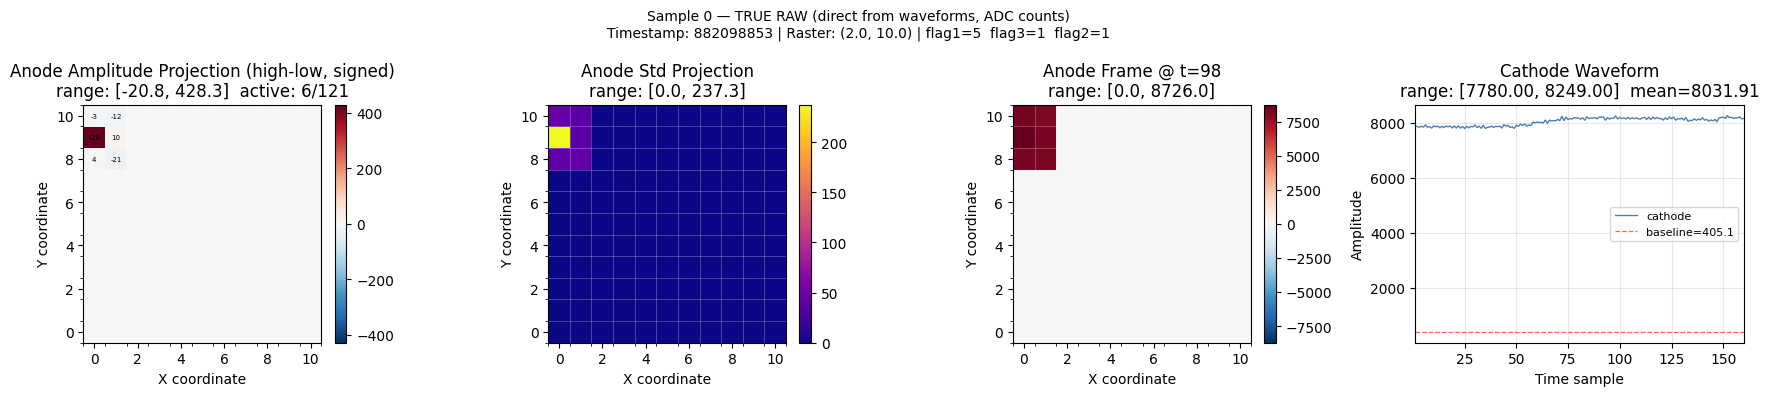


SAMPLE 0 — TRUE RAW (direct from waveforms, ADC counts)
Timestamp: 882098853 | Raster: (2.00, 10.00)
Channels: flag1=5  flag3=1  flag2=1

[Anode Amplitude Projection (high-low)]  range: [-20.8, 428.3]
          0     1     2     3     4     5     6     7     8     9    10
     ------------------------------------------------------------------
y= 0 |     @     @     @     @     @     @     @     @     @     @     @
y= 1 |     @     @     @     @     @     @     @     @     @     @     @
y= 2 |     @     @     @     @     @     @     @     @     @     @     @
y= 3 |     @     @     @     @     @     @     @     @     @     @     @
y= 4 |     @     @     @     @     @     @     @     @     @     @     @
y= 5 |     @     @     @     @     @     @     @     @     @     @     @
y= 6 |     @     @     @     @     @     @     @     @     @     @     @
y= 7 |     @     @     @     @     @     @     @     @     @     @     @
y= 8 |     4   -21     @     @     @     @     @     @     @     @    

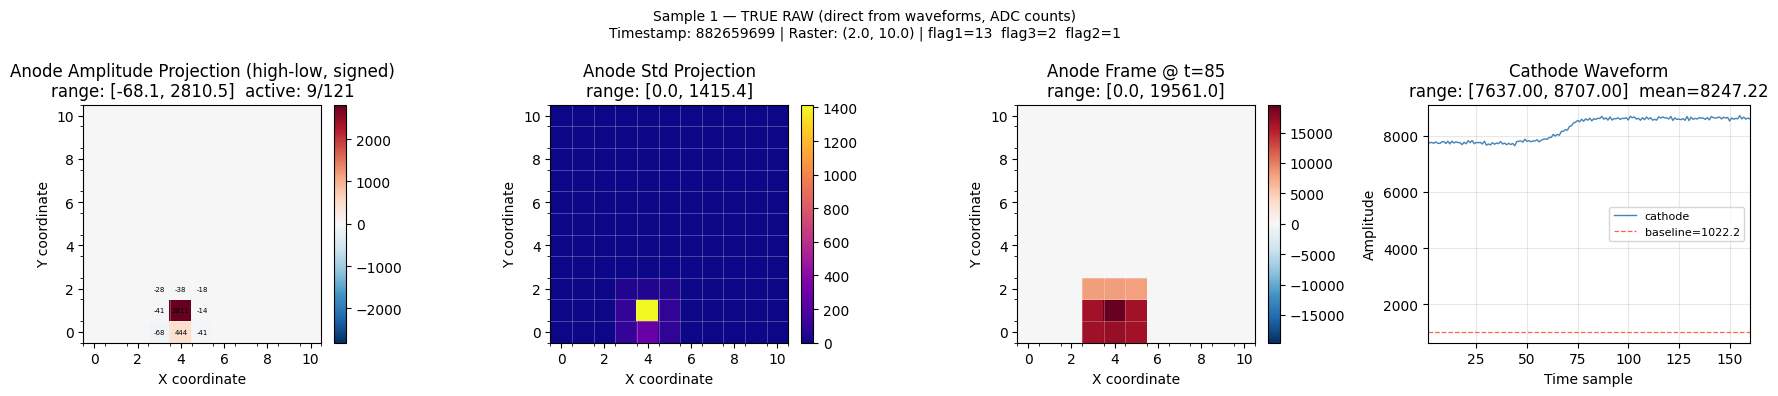


SAMPLE 1 — TRUE RAW (direct from waveforms, ADC counts)
Timestamp: 882659699 | Raster: (2.00, 10.00)
Channels: flag1=13  flag3=2  flag2=1

[Anode Amplitude Projection (high-low)]  range: [-68.1, 2810.5]
          0     1     2     3     4     5     6     7     8     9    10
     ------------------------------------------------------------------
y= 0 |     @     @     @   -68   444   -41     @     @     @     @     @
y= 1 |     @     @     @   -41  2811   -14     @     @     @     @     @
y= 2 |     @     @     @   -28   -38   -18     @     @     @     @     @
y= 3 |     @     @     @     @     @     @     @     @     @     @     @
y= 4 |     @     @     @     @     @     @     @     @     @     @     @
y= 5 |     @     @     @     @     @     @     @     @     @     @     @
y= 6 |     @     @     @     @     @     @     @     @     @     @     @
y= 7 |     @     @     @     @     @     @     @     @     @     @     @
y= 8 |     @     @     @     @     @     @     @     @     @     @  

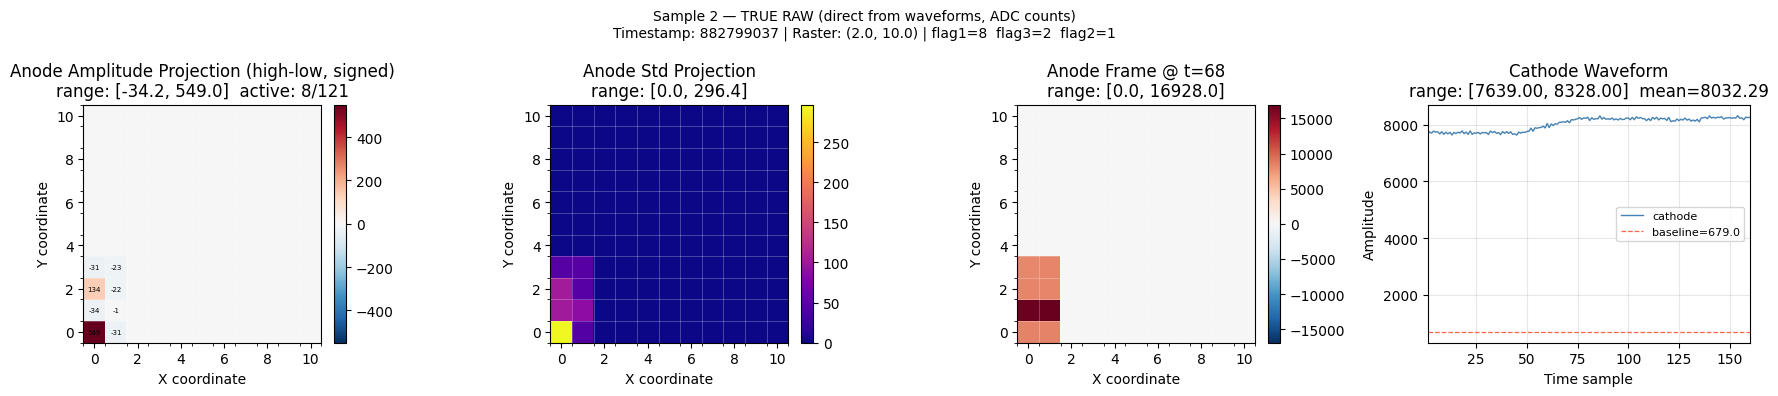


SAMPLE 2 — TRUE RAW (direct from waveforms, ADC counts)
Timestamp: 882799037 | Raster: (2.00, 10.00)
Channels: flag1=8  flag3=2  flag2=1

[Anode Amplitude Projection (high-low)]  range: [-34.2, 549.0]
          0     1     2     3     4     5     6     7     8     9    10
     ------------------------------------------------------------------
y= 0 |   549   -31     @     @     @     @     @     @     @     @     @
y= 1 |   -34    -1     @     @     @     @     @     @     @     @     @
y= 2 |   134   -22     @     @     @     @     @     @     @     @     @
y= 3 |   -31   -23     @     @     @     @     @     @     @     @     @
y= 4 |     @     @     @     @     @     @     @     @     @     @     @
y= 5 |     @     @     @     @     @     @     @     @     @     @     @
y= 6 |     @     @     @     @     @     @     @     @     @     @     @
y= 7 |     @     @     @     @     @     @     @     @     @     @     @
y= 8 |     @     @     @     @     @     @     @     @     @     @    

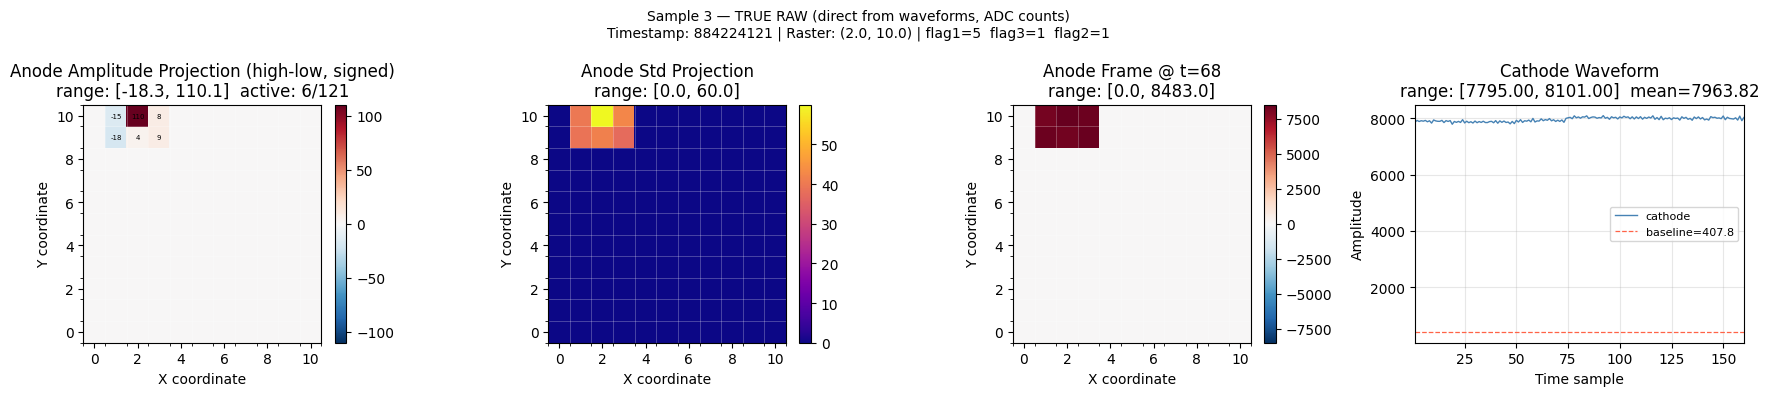


SAMPLE 3 — TRUE RAW (direct from waveforms, ADC counts)
Timestamp: 884224121 | Raster: (2.00, 10.00)
Channels: flag1=5  flag3=1  flag2=1

[Anode Amplitude Projection (high-low)]  range: [-18.3, 110.1]
          0     1     2     3     4     5     6     7     8     9    10
     ------------------------------------------------------------------
y= 0 |     @     @     @     @     @     @     @     @     @     @     @
y= 1 |     @     @     @     @     @     @     @     @     @     @     @
y= 2 |     @     @     @     @     @     @     @     @     @     @     @
y= 3 |     @     @     @     @     @     @     @     @     @     @     @
y= 4 |     @     @     @     @     @     @     @     @     @     @     @
y= 5 |     @     @     @     @     @     @     @     @     @     @     @
y= 6 |     @     @     @     @     @     @     @     @     @     @     @
y= 7 |     @     @     @     @     @     @     @     @     @     @     @
y= 8 |     @     @     @     @     @     @     @     @     @     @    

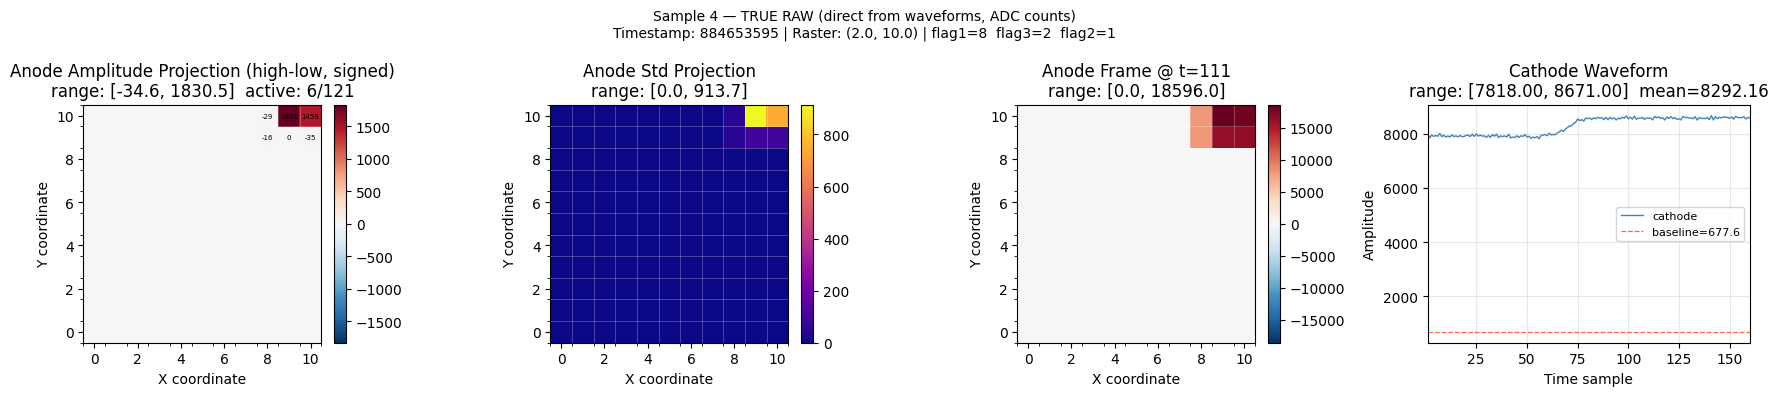


SAMPLE 4 — TRUE RAW (direct from waveforms, ADC counts)
Timestamp: 884653595 | Raster: (2.00, 10.00)
Channels: flag1=8  flag3=2  flag2=1

[Anode Amplitude Projection (high-low)]  range: [-34.6, 1830.5]
          0     1     2     3     4     5     6     7     8     9    10
     ------------------------------------------------------------------
y= 0 |     @     @     @     @     @     @     @     @     @     @     @
y= 1 |     @     @     @     @     @     @     @     @     @     @     @
y= 2 |     @     @     @     @     @     @     @     @     @     @     @
y= 3 |     @     @     @     @     @     @     @     @     @     @     @
y= 4 |     @     @     @     @     @     @     @     @     @     @     @
y= 5 |     @     @     @     @     @     @     @     @     @     @     @
y= 6 |     @     @     @     @     @     @     @     @     @     @     @
y= 7 |     @     @     @     @     @     @     @     @     @     @     @
y= 8 |     @     @     @     @     @     @     @     @     @     @   

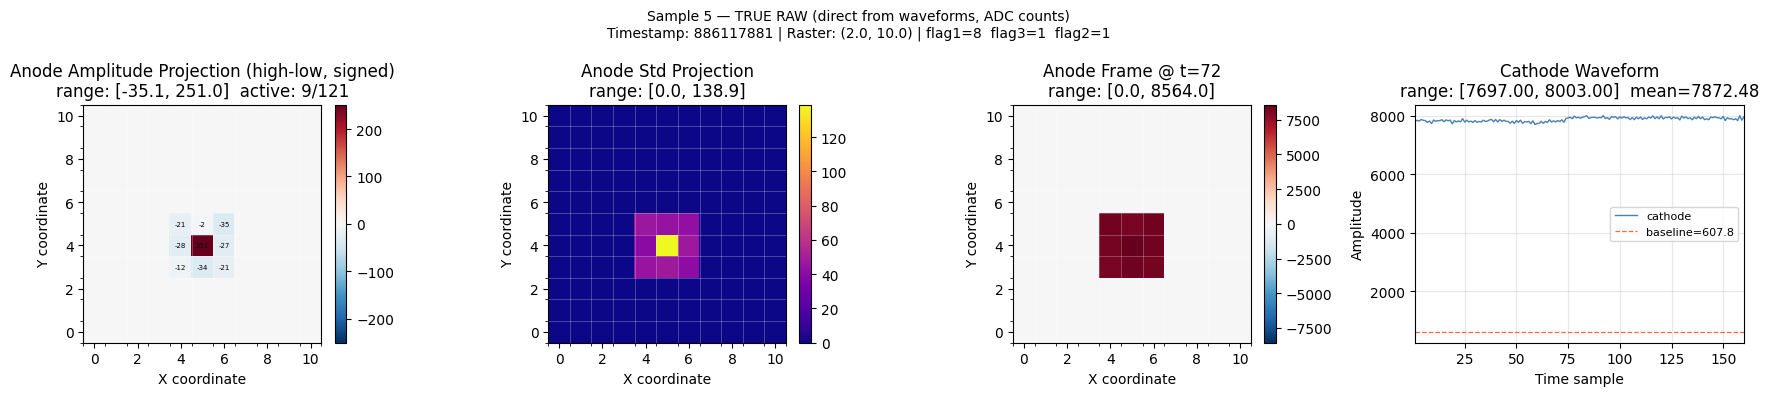


SAMPLE 5 — TRUE RAW (direct from waveforms, ADC counts)
Timestamp: 886117881 | Raster: (2.00, 10.00)
Channels: flag1=8  flag3=1  flag2=1

[Anode Amplitude Projection (high-low)]  range: [-35.1, 251.0]
          0     1     2     3     4     5     6     7     8     9    10
     ------------------------------------------------------------------
y= 0 |     @     @     @     @     @     @     @     @     @     @     @
y= 1 |     @     @     @     @     @     @     @     @     @     @     @
y= 2 |     @     @     @     @     @     @     @     @     @     @     @
y= 3 |     @     @     @     @   -12   -34   -21     @     @     @     @
y= 4 |     @     @     @     @   -28   251   -27     @     @     @     @
y= 5 |     @     @     @     @   -21    -2   -35     @     @     @     @
y= 6 |     @     @     @     @     @     @     @     @     @     @     @
y= 7 |     @     @     @     @     @     @     @     @     @     @     @
y= 8 |     @     @     @     @     @     @     @     @     @     @    

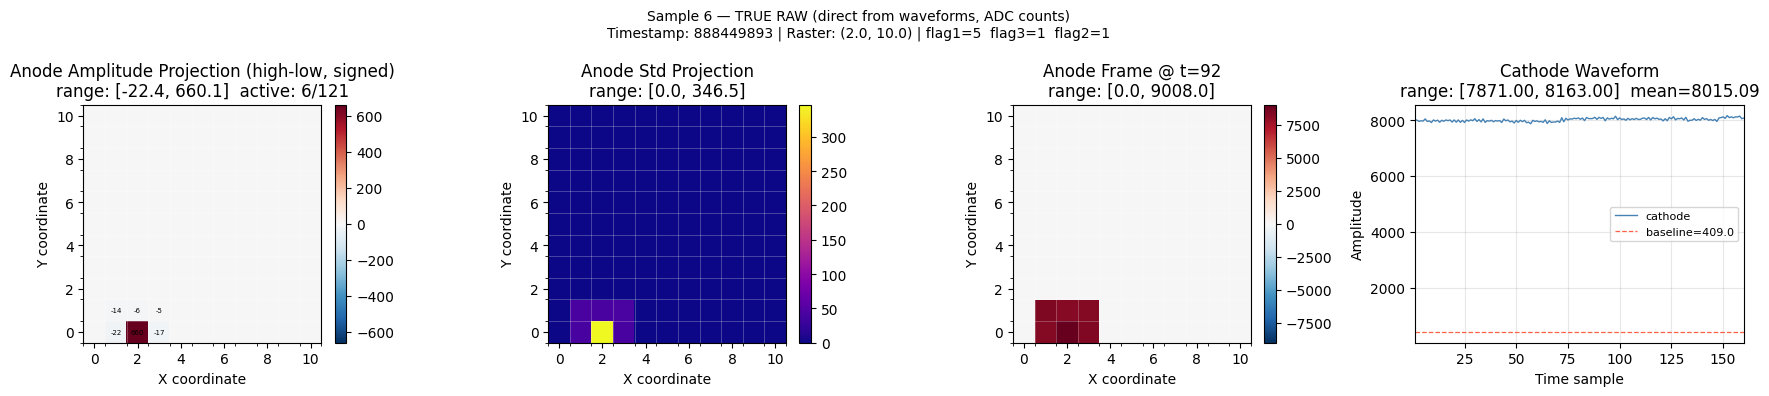


SAMPLE 6 — TRUE RAW (direct from waveforms, ADC counts)
Timestamp: 888449893 | Raster: (2.00, 10.00)
Channels: flag1=5  flag3=1  flag2=1

[Anode Amplitude Projection (high-low)]  range: [-22.4, 660.1]
          0     1     2     3     4     5     6     7     8     9    10
     ------------------------------------------------------------------
y= 0 |     @   -22   660   -17     @     @     @     @     @     @     @
y= 1 |     @   -14    -6    -5     @     @     @     @     @     @     @
y= 2 |     @     @     @     @     @     @     @     @     @     @     @
y= 3 |     @     @     @     @     @     @     @     @     @     @     @
y= 4 |     @     @     @     @     @     @     @     @     @     @     @
y= 5 |     @     @     @     @     @     @     @     @     @     @     @
y= 6 |     @     @     @     @     @     @     @     @     @     @     @
y= 7 |     @     @     @     @     @     @     @     @     @     @     @
y= 8 |     @     @     @     @     @     @     @     @     @     @    

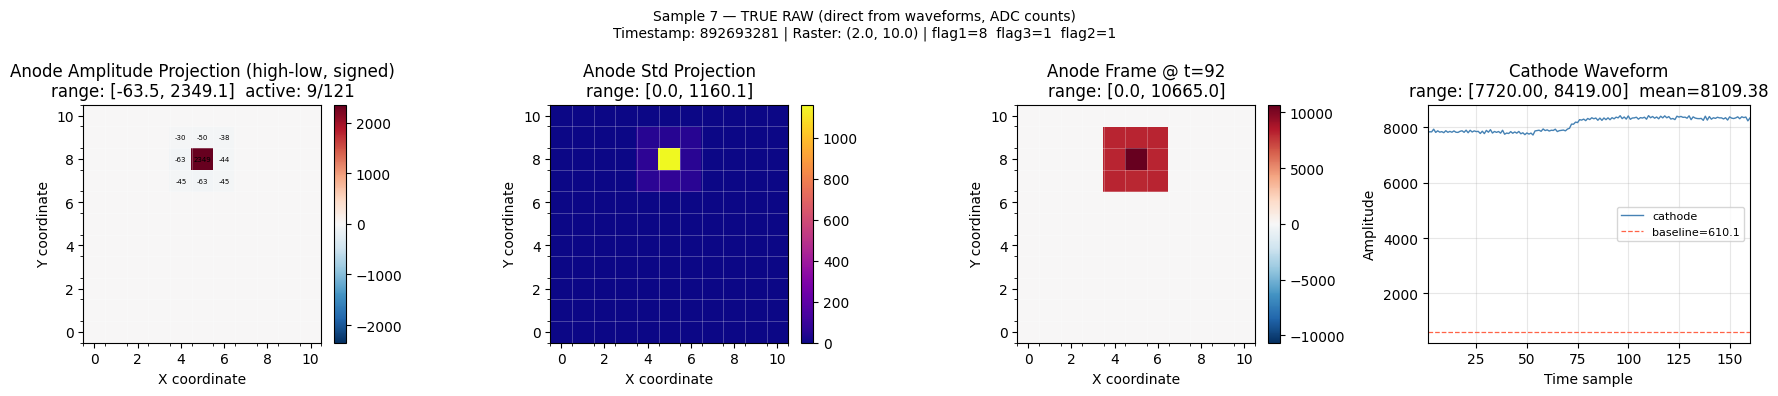


SAMPLE 7 — TRUE RAW (direct from waveforms, ADC counts)
Timestamp: 892693281 | Raster: (2.00, 10.00)
Channels: flag1=8  flag3=1  flag2=1

[Anode Amplitude Projection (high-low)]  range: [-63.5, 2349.1]
          0     1     2     3     4     5     6     7     8     9    10
     ------------------------------------------------------------------
y= 0 |     @     @     @     @     @     @     @     @     @     @     @
y= 1 |     @     @     @     @     @     @     @     @     @     @     @
y= 2 |     @     @     @     @     @     @     @     @     @     @     @
y= 3 |     @     @     @     @     @     @     @     @     @     @     @
y= 4 |     @     @     @     @     @     @     @     @     @     @     @
y= 5 |     @     @     @     @     @     @     @     @     @     @     @
y= 6 |     @     @     @     @     @     @     @     @     @     @     @
y= 7 |     @     @     @     @   -45   -63   -45     @     @     @     @
y= 8 |     @     @     @     @   -63  2349   -44     @     @     @   

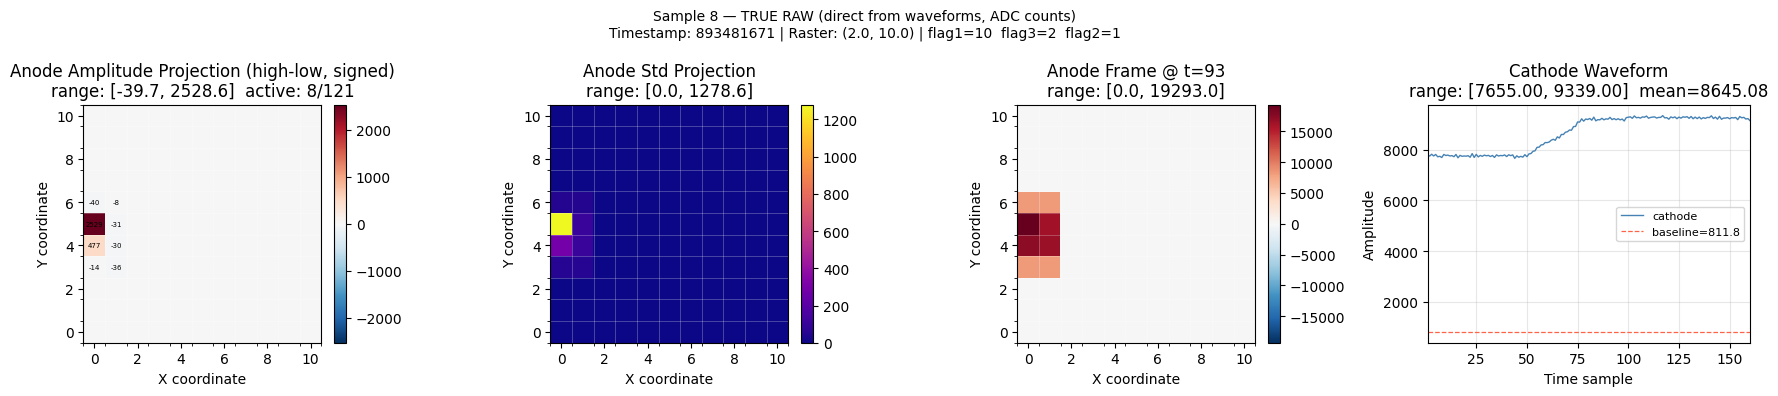


SAMPLE 8 — TRUE RAW (direct from waveforms, ADC counts)
Timestamp: 893481671 | Raster: (2.00, 10.00)
Channels: flag1=10  flag3=2  flag2=1

[Anode Amplitude Projection (high-low)]  range: [-39.7, 2528.6]
          0     1     2     3     4     5     6     7     8     9    10
     ------------------------------------------------------------------
y= 0 |     @     @     @     @     @     @     @     @     @     @     @
y= 1 |     @     @     @     @     @     @     @     @     @     @     @
y= 2 |     @     @     @     @     @     @     @     @     @     @     @
y= 3 |   -14   -36     @     @     @     @     @     @     @     @     @
y= 4 |   477   -30     @     @     @     @     @     @     @     @     @
y= 5 |  2529   -31     @     @     @     @     @     @     @     @     @
y= 6 |   -40    -8     @     @     @     @     @     @     @     @     @
y= 7 |     @     @     @     @     @     @     @     @     @     @     @
y= 8 |     @     @     @     @     @     @     @     @     @     @  

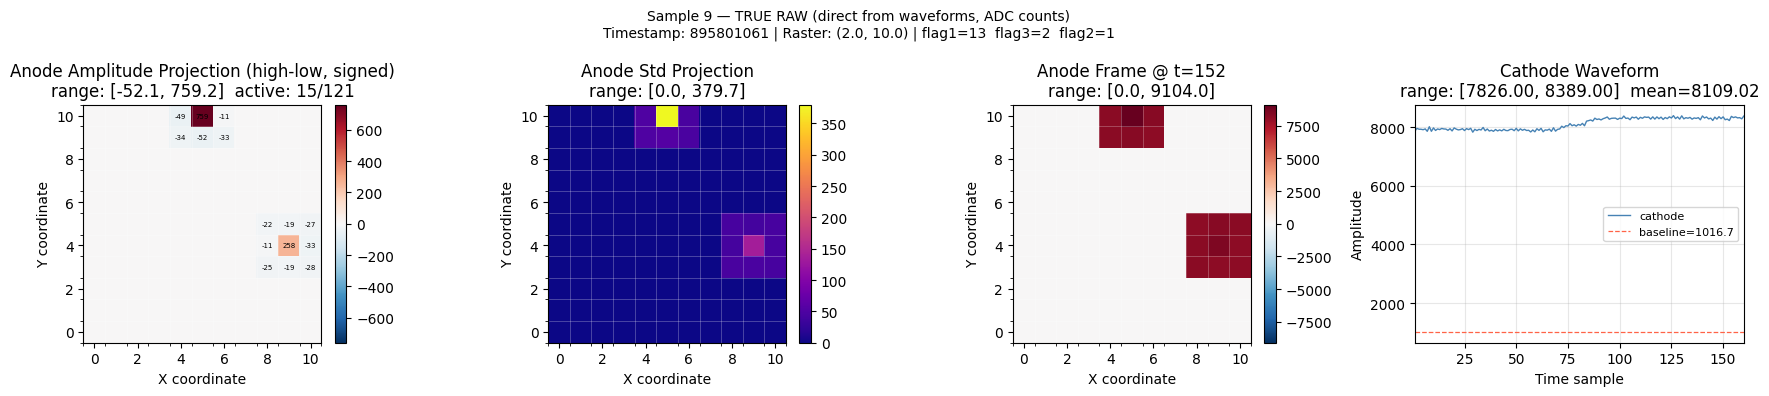


SAMPLE 9 — TRUE RAW (direct from waveforms, ADC counts)
Timestamp: 895801061 | Raster: (2.00, 10.00)
Channels: flag1=13  flag3=2  flag2=1

[Anode Amplitude Projection (high-low)]  range: [-52.1, 759.2]
          0     1     2     3     4     5     6     7     8     9    10
     ------------------------------------------------------------------
y= 0 |     @     @     @     @     @     @     @     @     @     @     @
y= 1 |     @     @     @     @     @     @     @     @     @     @     @
y= 2 |     @     @     @     @     @     @     @     @     @     @     @
y= 3 |     @     @     @     @     @     @     @     @   -25   -19   -28
y= 4 |     @     @     @     @     @     @     @     @   -11   258   -33
y= 5 |     @     @     @     @     @     @     @     @   -22   -19   -27
y= 6 |     @     @     @     @     @     @     @     @     @     @     @
y= 7 |     @     @     @     @     @     @     @     @     @     @     @
y= 8 |     @     @     @     @     @     @     @     @     @     @   

In [7]:
# @title Visualize Max Projection (UPDATED: amplitude-based projection + axis fixes)

"""
Renders a 4-panel summary for a single event (timestamp):
- Panel 0: anode AMPLITUDE map per pixel using (high-low) windows
- Panel 1: std projection over time per pixel (raw)
- Panel 2: a single frame snapshot at the global peak time (raw)
- Panel 3: cathode waveform (raw)

Fixes requested:
- origin='lower'
- extent = [-0.5, 10.5, -0.5, 10.5]
- consistent indexing [y, x, t] everywhere
- amplitude projection uses (high-low), consistent with dataset building/ground-truth
"""


def visualize_raw_sample(dataset, sample_idx=0, debug=True):
    meta = dataset.metadata[sample_idx]
    pos = dataset.raster_positions[sample_idx]
    timestamp = meta['timestamp']

    event_df = dataset.df[dataset.df['timestamp'] == timestamp]

    # Raw waveforms arranged as [y, x, t]
    pixel_raw = np.zeros((11, 11, 160), dtype=np.float32)
    cathode_raw = np.zeros(160, dtype=np.float32)

    wcfg = dataset.config['waveform']

    # Build SIGNED amplitude map [y, x] using (high-low)
    amplitude_map = np.zeros((11, 11), dtype=np.float32)

    for idx, row in event_df.iterrows():
        w = dataset.waveforms[idx].astype(np.float32)

        if row['channel_flag'] in [1, 3]:
            x_pos = int(row['x']) - 1
            y_pos = int(row['y']) - 1
            if 0 <= x_pos <= 11 and 0 <= y_pos <= 11:

                # Keep raw waveform at [y, x, t]
                pixel_raw[y_pos, x_pos, :] += w

                low = np.mean(w[wcfg["anode_low_lim"][0] : wcfg["anode_low_lim"][1]])
                high = np.mean(w[wcfg["anode_high_lim"][0] : wcfg["anode_high_lim"][1]])

                # FIX #1: DO NOT CLIP negatives; keep signed amplitude
                amplitude = float(high - low)

                # If multiple anodes contribute to same pixel, accumulate signed values
                amplitude_map[y_pos, x_pos] += amplitude

        elif row['channel_flag'] == 2:
            cathode_raw = w

    label = "TRUE RAW (direct from waveforms, ADC counts)"

    pixel_std = np.std(pixel_raw, axis=2)  # (11,11)
    peak_time = int(np.argmax(np.max(np.abs(pixel_raw), axis=(0, 1))))
    pixel_peak = pixel_raw[:, :, peak_time]  # (11,11)

    active_mask = amplitude_map != 0
    n_active = int(np.sum(active_mask))

    cmin, cmax = float(cathode_raw.min()), float(cathode_raw.max())
    baseline = np.mean(pixel_raw[:, :, :10], axis=2, keepdims=True)

    # Plot with requested coordinate system
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(
        f'Sample {sample_idx} — {label}\n'
        f'Timestamp: {timestamp} | Raster: ({pos[0]:.1f}, {pos[1]:.1f}) | '
        f'flag1={meta["num_channel1"]}  flag3={meta["num_channel3"]}  flag2={meta["num_channel2"]}',
        fontsize=10,
    )

    origin = 'lower'
    extent = [-0.5, 10.5, -0.5, 10.5]
    tick_locs = range(0, 11, 2)

    # FIX #2: make imshow behave like "cell grid" (no smoothing) and force limits
    def _apply_grid_axes(ax):
        ax.set_xlim(-0.5, 10.5)
        ax.set_ylim(-0.5, 10.5)
        ax.set_xticks(tick_locs)
        ax.set_yticks(tick_locs)
        ax.set_xlabel('X coordinate')
        ax.set_ylabel('Y coordinate')

        # Draw cell boundary gridlines at integer coords (matches your waveform-grid feel)
        ax.set_xticks(np.arange(-0.5, 11, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 11, 1), minor=True)
        ax.grid(which='minor', color='white', linewidth=0.5, alpha=0.35)

    # Panel 0 — SIGNED Anode amplitude projection (high-low)
    # Use diverging colormap and symmetric limits around 0 so negatives are visible
    amp_absmax = float(np.max(np.abs(amplitude_map))) or 1.0
    im0 = axes[0].imshow(
        amplitude_map,
        cmap='RdBu_r',
        origin=origin,
        extent=extent,
        aspect='equal',
        interpolation='nearest',
        vmin=-amp_absmax,
        vmax=amp_absmax,
    )
    axes[0].set_title(
        f'Anode Amplitude Projection (high-low, signed)\n'
        f'range: [{amplitude_map.min():.1f}, {amplitude_map.max():.1f}]  '
        f'active: {n_active}/121'
    )
    _apply_grid_axes(axes[0])
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # Annotate active pixels (signed)
    for y in range(11):
        for x in range(11):
            v = amplitude_map[y, x]
            if v != 0:
                axes[0].text(
                    x, y, f'{v:.0f}',
                    ha='center',
                    va='center',
                    fontsize=5,
                    color='black',
                )

    # Panel 1 — Anode std projection
    im1 = axes[1].imshow(
        pixel_std,
        cmap='plasma',
        origin=origin,
        extent=extent,
        aspect='equal',
        interpolation='nearest',
    )
    axes[1].set_title(f'Anode Std Projection\nrange: [{pixel_std.min():.1f}, {pixel_std.max():.1f}]')
    _apply_grid_axes(axes[1])
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # Panel 2 — Anode frame at peak time
    vmax = float(np.abs(pixel_peak).max()) or 1.0
    im2 = axes[2].imshow(
        pixel_peak,
        cmap='RdBu_r',
        origin=origin,
        extent=extent,
        aspect='equal',
        interpolation='nearest',
        vmin=-vmax,
        vmax=vmax,
    )
    axes[2].set_title(f'Anode Frame @ t={peak_time}\nrange: [{pixel_peak.min():.1f}, {pixel_peak.max():.1f}]')
    _apply_grid_axes(axes[2])
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    # Panel 3 — Cathode waveform
    t_axis = np.arange(1, 161)
    axes[3].plot(t_axis, cathode_raw, color='steelblue', linewidth=1.0, label='cathode')
    axes[3].axhline(baseline.mean(), color='tomato', linestyle='--', linewidth=0.9, label=f'baseline={baseline.mean():.1f}')
    axes[3].set_title(f'Cathode Waveform\nrange: [{cmin:.2f}, {cmax:.2f}]  mean={cathode_raw.mean():.2f}')
    axes[3].set_xlabel('Time sample')
    axes[3].set_ylabel('Amplitude')
    axes[3].legend(fontsize=8)
    axes[3].grid(True, alpha=0.3)
    axes[3].set_xlim(1, 160)

    plt.tight_layout()
    plt.show()

    # (debug printing unchanged, but note: it will now include negative values)

    if debug:
        print(f"\n{'='*60}")
        print(f"SAMPLE {sample_idx} — {label}")
        print(f"{'='*60}")
        print(f"Timestamp: {timestamp} | Raster: ({pos[0]:.2f}, {pos[1]:.2f})")
        print(f"Channels: flag1={meta['num_channel1']}  flag3={meta['num_channel3']}  flag2={meta['num_channel2']}")

        print(f"\n[Anode Amplitude Projection (high-low)]  range: [{amplitude_map.min():.1f}, {amplitude_map.max():.1f}]")
        print("     " + "".join(f"{x:>6}" for x in range(11)))
        print("     " + "------" * 11)
        for y in range(11):
            row_vals = "".join(f"{amplitude_map[y, x]:>6.0f}" if amplitude_map[y, x] != 0 else "     @" for x in range(11))
            print(f"y={y:2d} |{row_vals}")

        active = sorted([(y, x, amplitude_map[y, x]) for y in range(11) for x in range(11) if amplitude_map[y, x] != 0], key=lambda r: abs(r[2]), reverse=True)
        print(f"\nActive pixels: {len(active)}/121")
        for y, x, v in active:
            print(f"  (x={x}, y={y})  amplitude={v:.1f}")

        print(f"\n[Anode frame at t={peak_time}]  range: [{pixel_peak.min():.1f}, {pixel_peak.max():.1f}]")

        bins = np.array_split(cathode_raw, 16)
        bar_chars = ' ▁▂▃▄▅▆▇█'
        crange = cmax - cmin if cmax != cmin else 1.0
        bar = "".join(bar_chars[max(0, min(int((np.mean(b) - cmin) / crange * 8), 8))] * 2 for b in bins)
        print(f"\n[Cathode]  range: [{cmin:.2f}, {cmax:.2f}]  baseline={baseline.mean():.3f}")
        print(f"  {bar}")
        print(f"\nPixel  — min:{pixel_raw.min():.2f}  max:{pixel_raw.max():.2f}  mean:{pixel_raw.mean():.2f}")
        print(f"Cathode— min:{cmin:.2f}  max:{cmax:.2f}  mean:{cathode_raw.mean():.2f}")


n_samples = 10  # events to visualize
for idx in range(n_samples):
    visualize_raw_sample(dataset, sample_idx=idx, debug=True)

In [2]:
# @title Visualize Exact Event Match

'''
Renders a full 11×12 subplot grid where each cell contains the complete `160-sample waveform for that pixel`. It also:
- Applies curve fitting (stepish_func) to extract pulse times
- Overlays baseline markers (the magenta lines)
- Color-codes by channel flag (green=flag3 main, blue=flag1 neighbor, purple=flag2 cathode)
- Computes and displays Δt between cathode and anode pulse times

It shows the full waveform shape, not just max amplitude.
'''

def visualize_event_exact_match(data_loader, timestamp_index=0):
    timestamps = list(data_loader.event_groups.groups.keys()) #Get the event data
    timestamp = timestamps[timestamp_index]
    event_df = data_loader.event_groups.get_group(timestamp)

    print(f"Visualizing event with timestamp {timestamp}") #Print basic info
    print(f"Event has {len(event_df)} triggered pixels")

    # Create 11x12 grid
    fig, axs = plt.subplots(11, 12, figsize=(20, 10), sharex=True, sharey=True)

    # Hide the extra column subplots like he does
    for row in range(11):
        if row <= 1:
            continue
        axs[row, 11].set_visible(False)

    fig.suptitle(f"Timestamp {timestamp}")

    # Process each pixel
    amplitude_cathode = None
    t_anode = None
    t_cathode = None

    wcfg = data_loader.config['waveform']
    x = np.arange(160)  # Time samples

    for j, (idx, row) in enumerate(event_df.iterrows()): #Loop through each pixel
        w = data_loader.waveforms[event_df.index[j]]

        # EXACT SAME COORDINATE MAPPING
        if 255 in (row.x, row.y):
            ax = axs[0, 11]  # Special position for (255,255) coordinates
        else:
            # This is the key mapping: 11 - y, x - 1
            grid_row = 11 - int(row.y)
            grid_col = int(row.x) - 1
            ax = axs[grid_row, grid_col]

        # Add coordinate label like he does
        ax.text(0.95, 0.05, f"({row.x}, {row.y})", transform=ax.transAxes,
                fontsize=8, verticalalignment="bottom", horizontalalignment="right")

        # Same color scheme
        colors = {
            0: "tab:red",    # Unknown
            1: "tab:blue",   # Neighbour
            2: "tab:purple", # Cathode
            3: "tab:green",  # Anode
        }

        color = colors.get(row.channel_flag, "black")
        ax.plot(w, color, alpha=0.5)

        # Anode processing (channel_flag == 3)
        if row.channel_flag == 3:
            low = np.mean(w[wcfg["anode_low_lim"][0]:wcfg["anode_low_lim"][1]])
            high = np.mean(w[wcfg["anode_high_lim"][0]:wcfg["anode_high_lim"][1]])
            amplitude = high - low

            # Plot the baseline regions like he does
            ax.plot([wcfg["anode_low_lim"][0], wcfg["anode_low_lim"][1]], [low, low], "magenta")
            ax.plot([wcfg["anode_high_lim"][0], wcfg["anode_high_lim"][1]], [high, high], "magenta")

            # Curve fitting like he does
            try:
                popt, _ = curve_fit(stepish_func, x, w,
                                  p0=(np.nanmean(x), np.min(w), np.max(w) - np.min(w), 1.0, 1.0),
                                  maxfev=10000)
                t_anode = popt[0]
                ax.plot(x, stepish_func(x, *popt), 'r-', linewidth=0.5)

                ax.text(0.05, 0.95, f"A={amplitude:.2f}\nt={t_anode:.0f}",
                       transform=ax.transAxes, fontsize=8, verticalalignment="top")
            except:
                ax.text(0.05, 0.95, f"A={amplitude:.2f}",
                       transform=ax.transAxes, fontsize=8, verticalalignment="top")

        # Cathode processing (channel_flag == 2)
        elif row.channel_flag == 2:
            low = np.mean(w[wcfg["cathode_low_lim"][0]:wcfg["cathode_low_lim"][1]])
            high = np.mean(w[wcfg["cathode_high_lim"][0]:wcfg["cathode_high_lim"][1]])

            if amplitude_cathode is not None:
                print("Multiple cathode events in one timestamp")
                continue

            amplitude_cathode = high - low

            # Plot the baseline regions
            ax.plot([wcfg["cathode_low_lim"][0], wcfg["cathode_low_lim"][1]], [low, low], "magenta")
            ax.plot([wcfg["cathode_high_lim"][0], wcfg["cathode_high_lim"][1]], [high, high], "magenta")

            y = w
            popt, pocv = curve_fit(stepish_func, x, y, p0=(np.nanmean(x), np.min(y), np.max(y) - np.min(y), 1.0, 1.0), maxfev=1000000)
            t_cathode = popt[0]
            ax.plot(x, stepish_func(x, *popt), 'r-', linewidth=0.5)

            ax.text(0.05, 0.95, f"A={amplitude_cathode:.2f}\nt={t_cathode:.0f}", transform=ax.transAxes, fontsize=8, verticalalignment="top")

      # If neighbor pixel
        elif row.channel_flag == 1:
            low = np.mean(w[wcfg["anode_low_lim"][0]:wcfg["anode_low_lim"][1]])
            high = np.mean(w[wcfg["anode_high_lim"][0]:wcfg["anode_high_lim"][1]])
            amplitude = high - low

            ax.plot([wcfg["anode_low_lim"][0], wcfg["anode_low_lim"][1]], [low, low], "magenta", alpha=0.5)
            ax.plot([wcfg["anode_high_lim"][0], wcfg["anode_high_lim"][1]], [high, high], "magenta", alpha=0.5)

            # Curve fitting
            try:
                popt, _ = curve_fit(stepish_func, x, w,
                                  p0=(np.nanmean(x), np.min(w), np.max(w) - np.min(w), 1.0, 1.0),
                                  maxfev=10000)
                t_cathode = popt[0]
                ax.plot(x, stepish_func(x, *popt), 'r-', linewidth=0.5)

                ax.text(0.05, 0.95, f"A={amplitude_cathode:.2f}\nt={t_cathode:.0f}",
                       transform=ax.transAxes, fontsize=8, verticalalignment="top")
            except:
                ax.text(0.05, 0.95, f"A={amplitude_cathode:.2f}",
                       transform=ax.transAxes, fontsize=8, verticalalignment="top")

    # Add statistics box like he does
    if t_cathode is not None and t_anode is not None:
        nums = event_df.groupby("channel_flag").size()
        dt = t_cathode - t_anode

        info = "channel_flag amounts\n" + "\n".join([f"{k}: {v}" for k, v in nums.items()])
        info += f"\ndt = {dt:.0f} ns"

        axs[1, 11].text(0.5, 0.5, info, transform=axs[1, 11].transAxes,
                       fontsize=8, verticalalignment="center", horizontalalignment="center")
        axs[1, 11].axis("off")

    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()

def debug_coordinate_mapping(data_loader, timestamp_index=0):
    """Debug the coordinate mapping to understand the layout"""
    timestamps = list(data_loader.event_groups.groups.keys())
    timestamp = timestamps[timestamp_index]
    event_df = data_loader.event_groups.get_group(timestamp)

    print("Coordinate mapping debug:")
    print("Raw -> Grid mapping: (x, y) -> [11 - y, x - 1]")
    print()

    for idx, row in event_df.iterrows():
        if 255 in (row.x, row.y):
            grid_pos = "(0, 11) - SPECIAL"
        else:
            grid_row = 11 - int(row.y)
            grid_col = int(row.x) - 1
            grid_pos = f"[{grid_row}, {grid_col}]"

        print(f"Raw: ({row.x:3d}, {row.y:3d}) -> Grid: {grid_pos}")

# Debug the mapping first
print("Debugging coordinate mapping...")
debug_coordinate_mapping(dataset, 0)

print("\n" + "="*50)
print("Creating EXACT replica visualizations...")

# Create the exact replicas
for i in range(3):
    visualize_event_exact_match(dataset, i)
    print("-" * 50)

Debugging coordinate mapping...


NameError: name 'dataset' is not defined